# LLM Evaluation Results Analysis

## SED (String Edit Distance) Puzzle Benchmark

This notebook analyzes the performance of **3 LLaMA-family models** across **5 prompting techniques** on 32 SED puzzles.

### Models Evaluated
- **LLaMA 3.3 70B** - Large model (70B parameters)
- **LLaMA 4 Scout 17B** - Medium model (17B parameters)
- **LLaMA 3.1 8B** - Small model (8B parameters)

### Prompting Techniques
1. **Zero-Shot** - Direct instruction without examples
2. **Few-Shot** - 5 solved examples provided
3. **Chain-of-Thought (CoT)** - Step-by-step reasoning
4. **Self-Verify** - Propose → Simulate → Verify → Revise
5. **Role-Classify** - Classify rule roles before solving


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Professional styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16

# Color schemes
MODEL_COLORS = {
    'LLaMA 3.3 70B': '#3498db',   # Blue
    'LLaMA 4 Scout': '#e74c3c',   # Red  
    'LLaMA 3.1 8B': '#2ecc71',    # Green
}

PROMPT_COLORS = {
    'Zero-Shot': '#1abc9c',
    'Few-Shot': '#9b59b6',
    'CoT': '#e67e22',
    'Self-Verify': '#3498db',
    'Role-Classify': '#e74c3c',
}

DIFFICULTY_COLORS = {
    'easy': '#2ecc71',
    'medium': '#f39c12',
    'hard': '#e74c3c',
}

# Model display name mapping
MODEL_DISPLAY = {
    'llama-3.3-70b-versatile': 'LLaMA 3.3 70B',
    'meta-llama/llama-4-scout-17b-16e-instruct': 'LLaMA 4 Scout',
    'llama-3.1-8b-instant': 'LLaMA 3.1 8B',
}

PROMPT_DISPLAY = {
    'zero_shot': 'Zero-Shot',
    'few_shot': 'Few-Shot',
    'cot': 'CoT',
    'self_verify': 'Self-Verify',
    'role_classify': 'Role-Classify',
}

print("Setup complete!")


Setup complete!


## 1. Load Results Data


In [4]:
# Load all result files
results_dir = Path('../results')

models = ['llama-3.3-70b', 'llama-4-scout', 'llama-3.1-8b']
prompt_types = ['zero_shot', 'few_shot', 'cot', 'self_verify', 'role_classify']

# Load all summary files
all_results = {}
detailed_results = []

for model in models:
    all_results[model] = {}
    for pt in prompt_types:
        summary_file = results_dir / f"{model}_{pt}_summary.json"
        if summary_file.exists():
            with open(summary_file) as f:
                data = json.load(f)
                all_results[model][pt] = {
                    'model': data['model'],
                    'accuracy': data['accuracy'],
                    'correct': data['correct'],
                    'total': data['total_puzzles'],
                    'parsing_errors': data['parsing_errors'],
                    'invalid_solutions': data['invalid_solutions'],
                    'api_errors': data['api_errors'],
                    'avg_response_time': data['avg_response_time'],
                }
                # Store detailed results for per-puzzle analysis
                for result in data.get('results', []):
                    detailed_results.append({
                        'model': model,
                        'prompt_type': pt,
                        'problem_id': result['problem_id'],
                        'is_correct': result['is_correct'],
                        'error_type': result.get('error_type'),
                        'response_time': result.get('response_time', 0),
                    })

# Load metadata for difficulty info
with open('../data/metadata.json') as f:
    metadata = json.load(f)
metadata_dict = {m['problem_id']: m for m in metadata}

# Create detailed DataFrame
df_detailed = pd.DataFrame(detailed_results)

# Add difficulty info
df_detailed['difficulty'] = df_detailed['problem_id'].map(
    lambda x: metadata_dict.get(x, {}).get('difficulty_level', 'unknown')
)
df_detailed['generator'] = df_detailed['problem_id'].map(
    lambda x: metadata_dict.get(x, {}).get('generator', 'unknown')
)

print(f"Loaded results for {len(models)} models × {len(prompt_types)} prompt types")
print(f"Total evaluations: {len(df_detailed)}")


Loaded results for 3 models × 5 prompt types
Total evaluations: 480


## 2. Overall Performance Summary


In [5]:
# Build comprehensive comparison DataFrame
comparison_data = []

model_name_map = {
    'llama-3.3-70b': 'LLaMA 3.3 70B',
    'llama-4-scout': 'LLaMA 4 Scout',
    'llama-3.1-8b': 'LLaMA 3.1 8B',
}

for model in models:
    for pt in prompt_types:
        if pt in all_results[model]:
            data = all_results[model][pt]
            comparison_data.append({
                'Model': model_name_map[model],
                'Prompt Type': PROMPT_DISPLAY[pt],
                'Accuracy (%)': data['accuracy'] * 100,
                'Correct': data['correct'],
                'Total': data['total'],
                'Parsing Errors': data['parsing_errors'],
                'Invalid Solutions': data['invalid_solutions'],
                'API Errors': data['api_errors'],
                'Avg Response Time (s)': data['avg_response_time'],
                'model_key': model,
                'prompt_key': pt,
            })

df_comparison = pd.DataFrame(comparison_data)

# Display summary table
print("="*80)
print("OVERALL PERFORMANCE SUMMARY")
print("="*80)

pivot_display = df_comparison.pivot_table(
    values='Accuracy (%)', 
    index='Model', 
    columns='Prompt Type',
    aggfunc='mean'
).round(1)

# Reorder columns
col_order = ['Zero-Shot', 'Few-Shot', 'CoT', 'Self-Verify', 'Role-Classify']
pivot_display = pivot_display[[c for c in col_order if c in pivot_display.columns]]

print("\n📊 Accuracy by Model and Prompt Type (%):\n")
print(pivot_display.to_string())

# Best combinations
print("\n" + "="*80)
print("🏆 TOP 5 MODEL-PROMPT COMBINATIONS")
print("="*80)
top5 = df_comparison.nlargest(5, 'Accuracy (%)')
for i, row in top5.iterrows():
    print(f"  {row['Model']} + {row['Prompt Type']}: {row['Accuracy (%)']:.1f}% ({row['Correct']}/{row['Total']})")


OVERALL PERFORMANCE SUMMARY

📊 Accuracy by Model and Prompt Type (%):

Prompt Type    Zero-Shot  Few-Shot   CoT  Self-Verify  Role-Classify
Model                                                               
LLaMA 3.1 8B         6.2       9.4  15.6          6.2           18.8
LLaMA 3.3 70B       31.2      34.4  31.2         31.2           28.1
LLaMA 4 Scout       37.5      43.8  37.5         25.0           34.4

🏆 TOP 5 MODEL-PROMPT COMBINATIONS
  LLaMA 4 Scout + Few-Shot: 43.8% (14/32)
  LLaMA 4 Scout + Zero-Shot: 37.5% (12/32)
  LLaMA 4 Scout + CoT: 37.5% (12/32)
  LLaMA 3.3 70B + Few-Shot: 34.4% (11/32)
  LLaMA 4 Scout + Role-Classify: 34.4% (11/32)


## 3. Model Performance Comparison


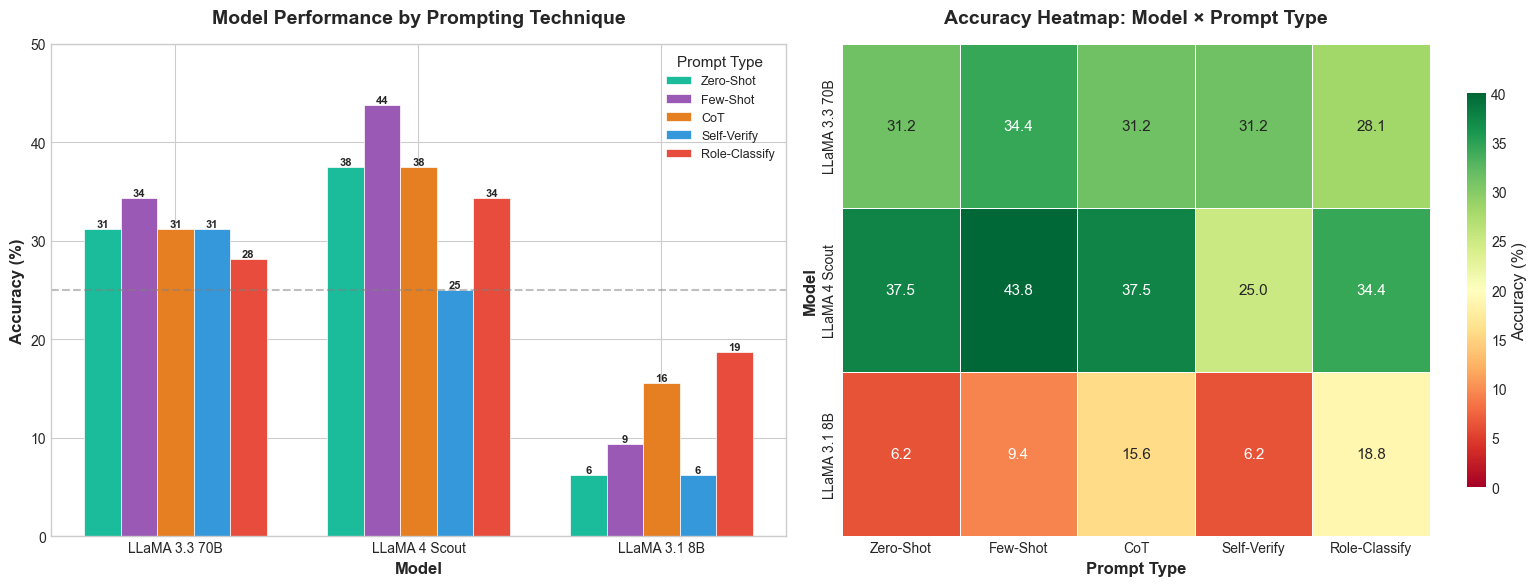


Key Observations:
  • Best Model (avg): LLaMA 4 Scout (35.6%)
  • Best Prompt Type (avg): Few-Shot (29.2%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pivot for heatmap
pivot_accuracy = df_comparison.pivot_table(
    values='Accuracy (%)', 
    index='Model', 
    columns='Prompt Type',
    aggfunc='mean'
)

# Reorder
col_order = ['Zero-Shot', 'Few-Shot', 'CoT', 'Self-Verify', 'Role-Classify']
pivot_accuracy = pivot_accuracy[[c for c in col_order if c in pivot_accuracy.columns]]
row_order = ['LLaMA 3.3 70B', 'LLaMA 4 Scout', 'LLaMA 3.1 8B']
pivot_accuracy = pivot_accuracy.reindex([r for r in row_order if r in pivot_accuracy.index])

# 1. Grouped Bar Chart
ax1 = axes[0]
x = np.arange(len(pivot_accuracy.index))
width = 0.15

for i, pt in enumerate(pivot_accuracy.columns):
    values = pivot_accuracy[pt].values
    bars = ax1.bar(x + i*width, values, width, 
                  label=pt, color=list(PROMPT_COLORS.values())[i],
                  edgecolor='white', linewidth=0.5)
    # Add value labels
    for bar, val in zip(bars, values):
        if not np.isnan(val):
            ax1.annotate(f'{val:.0f}',
                        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_xlabel('Model', fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontweight='bold')
ax1.set_title('Model Performance by Prompting Technique', fontweight='bold', pad=15)
ax1.set_xticks(x + width * 2)
ax1.set_xticklabels(pivot_accuracy.index, rotation=0)
ax1.legend(title='Prompt Type', loc='upper right', fontsize=9)
ax1.set_ylim(0, 50)
ax1.axhline(y=25, color='gray', linestyle='--', alpha=0.5, label='Random baseline')

# 2. Heatmap
ax2 = axes[1]
sns.heatmap(pivot_accuracy, annot=True, fmt='.1f', cmap='RdYlGn',
            center=20, vmin=0, vmax=40, ax=ax2,
            cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
            linewidths=0.5, linecolor='white')
ax2.set_title('Accuracy Heatmap: Model × Prompt Type', fontweight='bold', pad=15)
ax2.set_xlabel('Prompt Type', fontweight='bold')
ax2.set_ylabel('Model', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/model_prompt_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Key insights
print("\nKey Observations:")
best_model = pivot_accuracy.mean(axis=1).idxmax()
best_prompt = pivot_accuracy.mean(axis=0).idxmax()
print(f"  • Best Model (avg): {best_model} ({pivot_accuracy.mean(axis=1).max():.1f}%)")
print(f"  • Best Prompt Type (avg): {best_prompt} ({pivot_accuracy.mean(axis=0).max():.1f}%)")


## 4. Performance by Difficulty Level


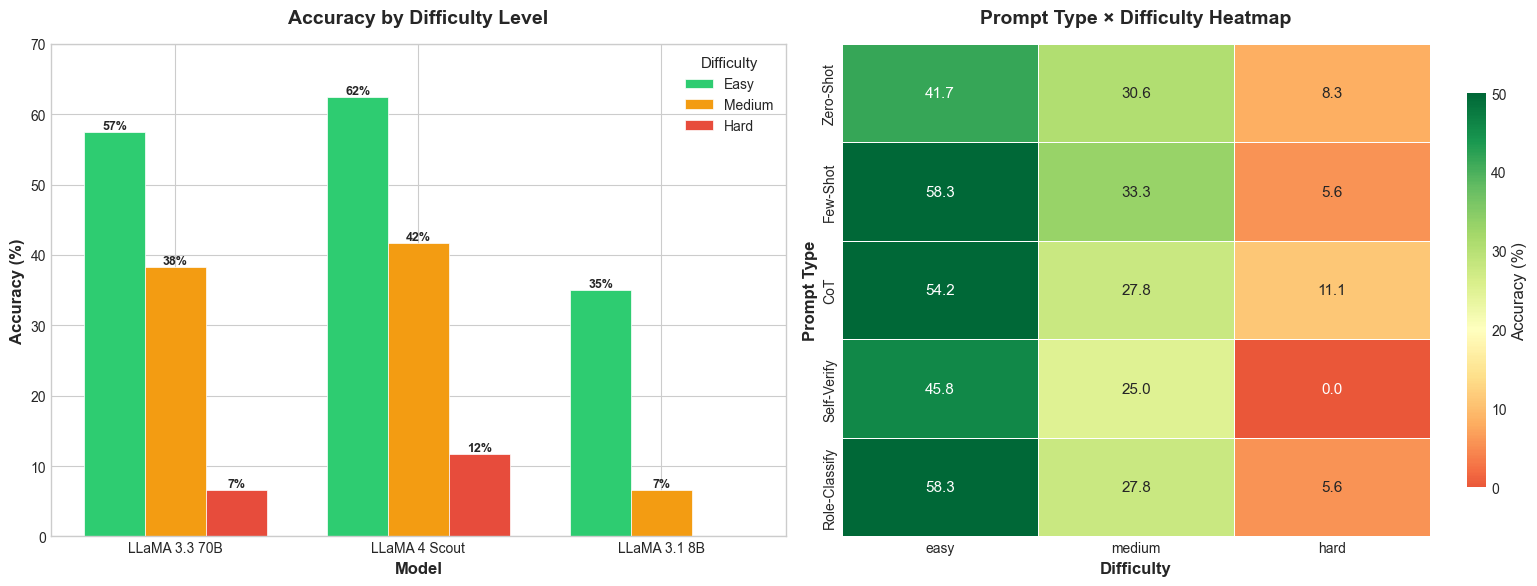


Difficulty Analysis:
  • Easy: 51.7% average accuracy
  • Medium: 28.9% average accuracy
  • Hard: 6.1% average accuracy


In [9]:
# Calculate accuracy by model and difficulty
difficulty_perf = df_detailed.groupby(['model', 'difficulty']).agg(
    correct=('is_correct', 'sum'),
    total=('is_correct', 'count')
).reset_index()
difficulty_perf['accuracy'] = difficulty_perf['correct'] / difficulty_perf['total'] * 100
difficulty_perf['model_display'] = difficulty_perf['model'].map(model_name_map)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Grouped bar chart by difficulty
ax1 = axes[0]
pivot_diff = difficulty_perf.pivot(index='model_display', columns='difficulty', values='accuracy')
diff_order = ['easy', 'medium', 'hard']
pivot_diff = pivot_diff[[d for d in diff_order if d in pivot_diff.columns]]
model_order = ['LLaMA 3.3 70B', 'LLaMA 4 Scout', 'LLaMA 3.1 8B']
pivot_diff = pivot_diff.reindex([m for m in model_order if m in pivot_diff.index])

x = np.arange(len(pivot_diff.index))
width = 0.25

for i, diff in enumerate(pivot_diff.columns):
    values = pivot_diff[diff].fillna(0).values
    bars = ax1.bar(x + i*width, values, width,
                  label=diff.capitalize(), color=DIFFICULTY_COLORS[diff],
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        if val > 0:
            ax1.annotate(f'{val:.0f}%',
                        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xlabel('Model', fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontweight='bold')
ax1.set_title('Accuracy by Difficulty Level', fontweight='bold', pad=15)
ax1.set_xticks(x + width)
ax1.set_xticklabels(pivot_diff.index)
ax1.legend(title='Difficulty')
ax1.set_ylim(0, 70)

# 2. Heatmap: Prompt type × Difficulty
ax2 = axes[1]
prompt_diff = df_detailed.groupby(['prompt_type', 'difficulty']).agg(
    accuracy=('is_correct', 'mean')
).reset_index()
prompt_diff['accuracy'] = prompt_diff['accuracy'] * 100
prompt_diff['prompt_display'] = prompt_diff['prompt_type'].map(PROMPT_DISPLAY)

pivot_prompt_diff = prompt_diff.pivot(index='prompt_display', columns='difficulty', values='accuracy')
pivot_prompt_diff = pivot_prompt_diff[[d for d in diff_order if d in pivot_prompt_diff.columns]]
prompt_order = ['Zero-Shot', 'Few-Shot', 'CoT', 'Self-Verify', 'Role-Classify']
pivot_prompt_diff = pivot_prompt_diff.reindex([p for p in prompt_order if p in pivot_prompt_diff.index])

sns.heatmap(pivot_prompt_diff, annot=True, fmt='.1f', cmap='RdYlGn',
            center=20, vmin=0, vmax=50, ax=ax2,
            cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
            linewidths=0.5, linecolor='white')
ax2.set_title('Prompt Type × Difficulty Heatmap', fontweight='bold', pad=15)
ax2.set_xlabel('Difficulty', fontweight='bold')
ax2.set_ylabel('Prompt Type', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/difficulty_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\nDifficulty Analysis:")
for diff in ['easy', 'medium', 'hard']:
    avg = df_detailed[df_detailed['difficulty'] == diff]['is_correct'].mean() * 100
    print(f"  • {diff.capitalize()}: {avg:.1f}% average accuracy")


## 5. Prompting Technique Analysis


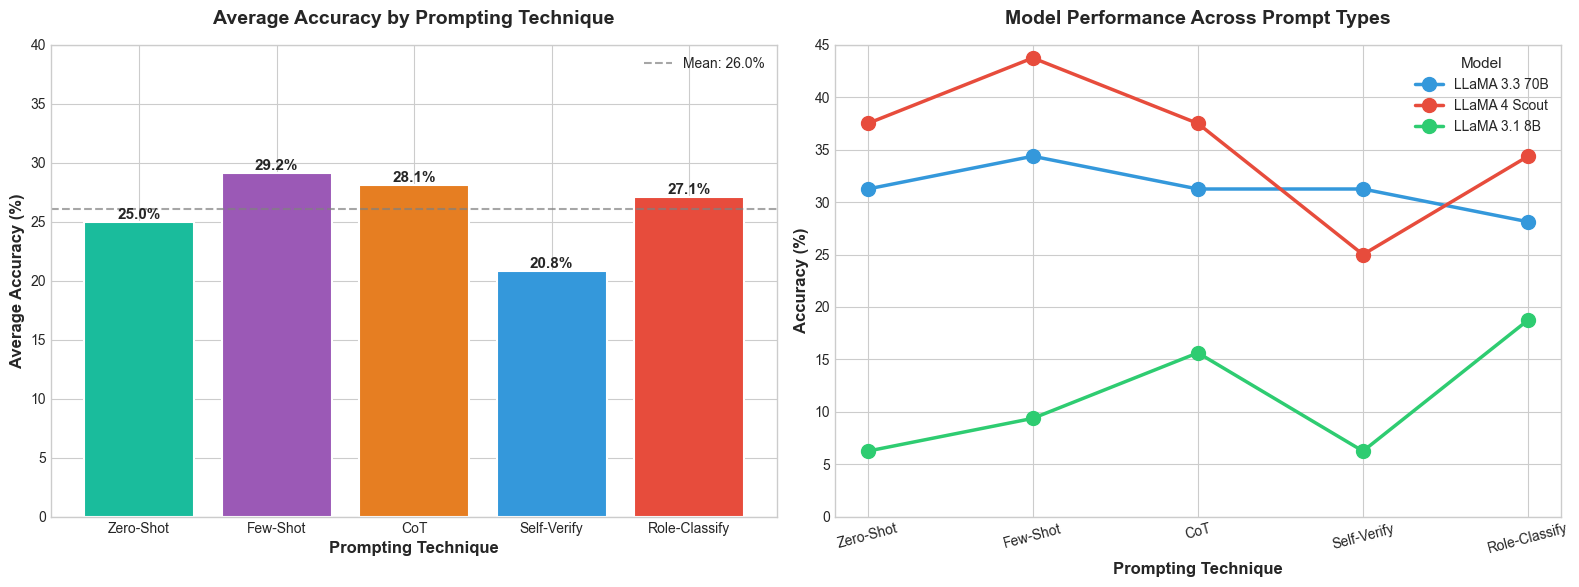


Prompting Technique Rankings (by average accuracy):
  1. Few-Shot: 29.2%
  2. CoT: 28.1%
  3. Role-Classify: 27.1%
  4. Zero-Shot: 25.0%
  5. Self-Verify: 20.8%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Average accuracy by prompt type
ax1 = axes[0]
prompt_avg = df_comparison.groupby('Prompt Type')['Accuracy (%)'].mean().reindex(
    ['Zero-Shot', 'Few-Shot', 'CoT', 'Self-Verify', 'Role-Classify']
)

colors = [PROMPT_COLORS[p] for p in prompt_avg.index]
bars = ax1.bar(prompt_avg.index, prompt_avg.values, color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, prompt_avg.values):
    ax1.annotate(f'{val:.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xlabel('Prompting Technique', fontweight='bold')
ax1.set_ylabel('Average Accuracy (%)', fontweight='bold')
ax1.set_title('Average Accuracy by Prompting Technique', fontweight='bold', pad=15)
ax1.set_ylim(0, 40)
ax1.axhline(y=prompt_avg.mean(), color='gray', linestyle='--', alpha=0.7, label=f'Mean: {prompt_avg.mean():.1f}%')
ax1.legend()

# 2. Prompt effectiveness by model (line plot)
ax2 = axes[1]

for model in model_order:
    model_data = df_comparison[df_comparison['Model'] == model]
    model_data = model_data.set_index('Prompt Type').reindex(prompt_order)
    ax2.plot(model_data.index, model_data['Accuracy (%)'], 
            marker='o', markersize=10, linewidth=2.5,
            color=MODEL_COLORS[model], label=model)

ax2.set_xlabel('Prompting Technique', fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontweight='bold')
ax2.set_title('Model Performance Across Prompt Types', fontweight='bold', pad=15)
ax2.legend(title='Model', loc='upper right')
ax2.set_ylim(0, 45)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../results/prompt_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Statistical summary
print("\nPrompting Technique Rankings (by average accuracy):")
for i, (pt, acc) in enumerate(prompt_avg.sort_values(ascending=False).items(), 1):
    print(f"  {i}. {pt}: {acc:.1f}%")


## 6. Error Analysis


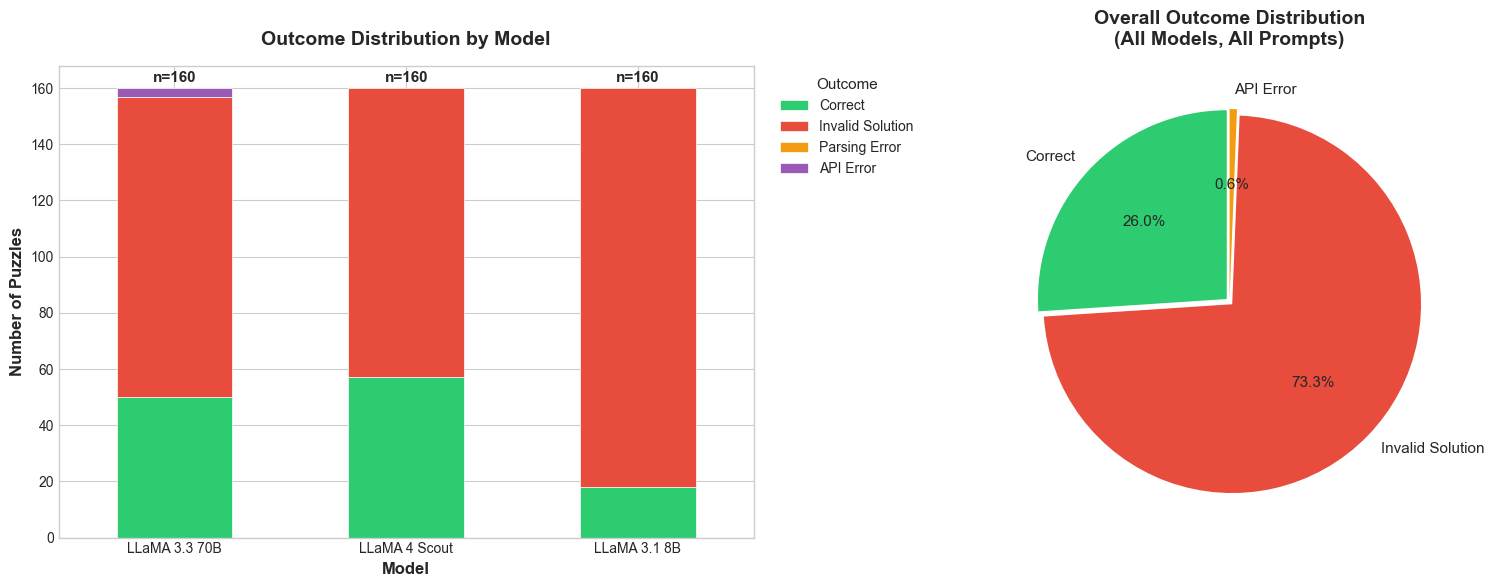


Error Analysis Summary:
  • Total Evaluations: 480
  • Correct: 125 (26.0%)
  • Invalid Solutions: 352 (73.3%)
  • API Errors: 3 (0.6%)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate error breakdown by model
error_data = []
for model in models:
    model_name = model_name_map[model]
    total_correct = 0
    total_invalid = 0
    total_parsing = 0
    total_api = 0
    total = 0
    
    for pt in prompt_types:
        if pt in all_results[model]:
            data = all_results[model][pt]
            total_correct += data['correct']
            total_invalid += data['invalid_solutions']
            total_parsing += data['parsing_errors']
            total_api += data['api_errors']
            total += data['total']
    
    error_data.append({
        'Model': model_name,
        'Correct': total_correct,
        'Invalid Solution': total_invalid,
        'Parsing Error': total_parsing,
        'API Error': total_api,
    })

df_errors = pd.DataFrame(error_data)
df_errors = df_errors.set_index('Model')

# 1. Stacked bar chart
ax1 = axes[0]
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
df_errors.plot(kind='bar', stacked=True, ax=ax1, color=colors, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Model', fontweight='bold')
ax1.set_ylabel('Number of Puzzles', fontweight='bold')
ax1.set_title('Outcome Distribution by Model', fontweight='bold', pad=15)
ax1.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=0)

# Add total labels
for i, model in enumerate(df_errors.index):
    total = df_errors.loc[model].sum()
    ax1.annotate(f'n={int(total)}', xy=(i, total + 2), ha='center', fontweight='bold')

# 2. Error breakdown pie chart (overall)
ax2 = axes[1]
total_outcomes = df_errors.sum()
total_outcomes = total_outcomes[total_outcomes > 0]  # Remove zero categories

wedges, texts, autotexts = ax2.pie(
    total_outcomes.values,
    labels=total_outcomes.index,
    autopct='%1.1f%%',
    colors=colors[:len(total_outcomes)],
    explode=[0.02] * len(total_outcomes),
    startangle=90,
    textprops={'fontsize': 11}
)
ax2.set_title('Overall Outcome Distribution\n(All Models, All Prompts)', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../results/error_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Summary stats
print("\nError Analysis Summary:")
total_evaluations = df_errors.sum().sum()
print(f"  • Total Evaluations: {int(total_evaluations)}")
print(f"  • Correct: {int(df_errors['Correct'].sum())} ({df_errors['Correct'].sum()/total_evaluations*100:.1f}%)")
print(f"  • Invalid Solutions: {int(df_errors['Invalid Solution'].sum())} ({df_errors['Invalid Solution'].sum()/total_evaluations*100:.1f}%)")
print(f"  • API Errors: {int(df_errors['API Error'].sum())} ({df_errors['API Error'].sum()/total_evaluations*100:.1f}%)")


## 7. Response Time Analysis


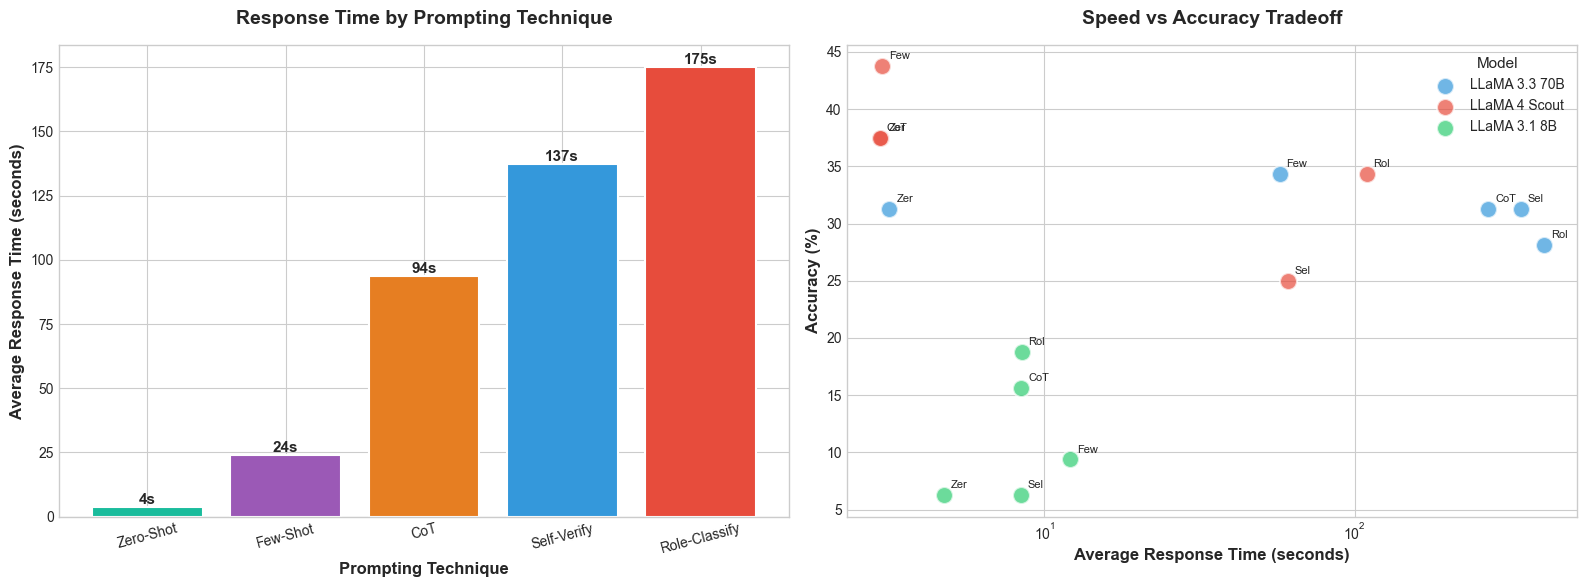


⏱️ Response Time Analysis:
  • Fastest prompt: Zero-Shot (3.6s)
  • Slowest prompt: Role-Classify (175.0s)
  • Slowest is 48x slower than fastest


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Response time by prompt type
ax1 = axes[0]
time_by_prompt = df_comparison.groupby('Prompt Type')['Avg Response Time (s)'].mean().reindex(prompt_order)

colors = [PROMPT_COLORS[p] for p in time_by_prompt.index]
bars = ax1.bar(time_by_prompt.index, time_by_prompt.values, color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, time_by_prompt.values):
    ax1.annotate(f'{val:.0f}s',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xlabel('Prompting Technique', fontweight='bold')
ax1.set_ylabel('Average Response Time (seconds)', fontweight='bold')
ax1.set_title('Response Time by Prompting Technique', fontweight='bold', pad=15)
ax1.tick_params(axis='x', rotation=15)

# 2. Speed vs Accuracy tradeoff
ax2 = axes[1]
for model in model_order:
    model_data = df_comparison[df_comparison['Model'] == model]
    ax2.scatter(model_data['Avg Response Time (s)'], model_data['Accuracy (%)'],
               s=150, alpha=0.7, color=MODEL_COLORS[model], label=model,
               edgecolor='white', linewidth=1.5)
    
    # Add prompt type labels
    for _, row in model_data.iterrows():
        ax2.annotate(row['Prompt Type'][:3], 
                    xy=(row['Avg Response Time (s)'], row['Accuracy (%)']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

ax2.set_xlabel('Average Response Time (seconds)', fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontweight='bold')
ax2.set_title('Speed vs Accuracy Tradeoff', fontweight='bold', pad=15)
ax2.legend(title='Model')
ax2.set_xscale('log')  # Log scale for time due to large variation

plt.tight_layout()
plt.savefig('../results/response_time_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n⏱️ Response Time Analysis:")
print(f"  • Fastest prompt: {time_by_prompt.idxmin()} ({time_by_prompt.min():.1f}s)")
print(f"  • Slowest prompt: {time_by_prompt.idxmax()} ({time_by_prompt.max():.1f}s)")
print(f"  • Slowest is {time_by_prompt.max()/time_by_prompt.min():.0f}x slower than fastest")


## 8. Per-Puzzle Success Analysis


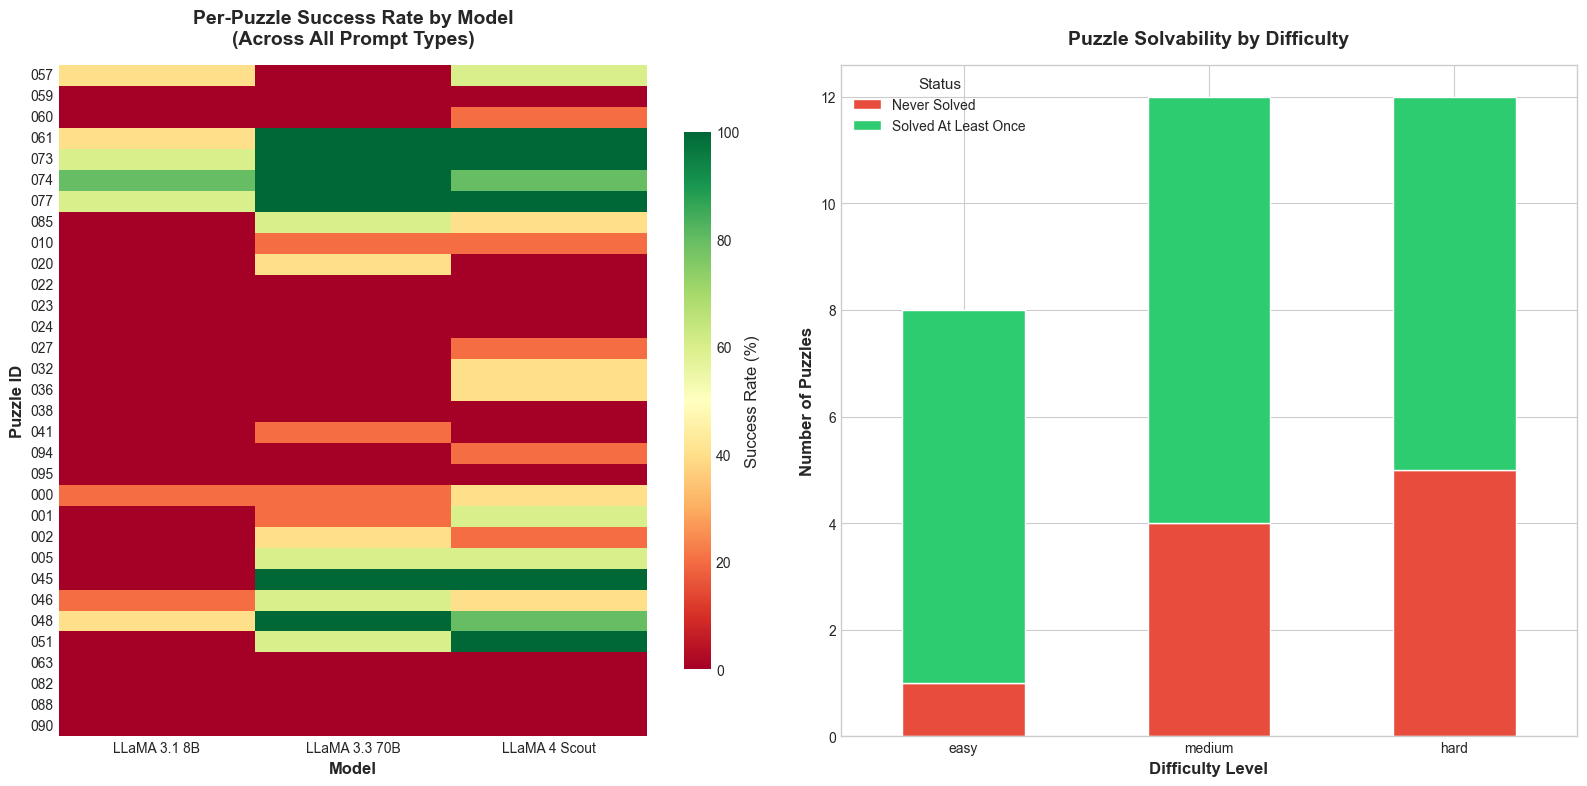


🧩 Puzzle Difficulty Insights:

  Easiest puzzles (highest success rate):
    • 073 (easy): 86.7%
    • 074 (easy): 86.7%
    • 077 (easy): 86.7%

  Hardest puzzles (lowest success rate):
    • 022 (hard): 0.0%
    • 023 (hard): 0.0%
    • 024 (hard): 0.0%


In [15]:
# Which puzzles are solved by which models?
puzzle_success = df_detailed.groupby(['problem_id', 'model']).agg(
    times_correct=('is_correct', 'sum'),
    times_tested=('is_correct', 'count')
).reset_index()
puzzle_success['success_rate'] = puzzle_success['times_correct'] / puzzle_success['times_tested'] * 100

# Pivot for heatmap
puzzle_pivot = puzzle_success.pivot(index='problem_id', columns='model', values='success_rate').fillna(0)
puzzle_pivot.columns = [model_name_map[m] for m in puzzle_pivot.columns]

# Add difficulty info
puzzle_pivot['difficulty'] = puzzle_pivot.index.map(lambda x: metadata_dict.get(x, {}).get('difficulty_level', 'unknown'))
puzzle_pivot = puzzle_pivot.sort_values(['difficulty', puzzle_pivot.index.name])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Puzzle success heatmap
ax1 = axes[0]
heatmap_data = puzzle_pivot.drop(columns='difficulty')

sns.heatmap(heatmap_data, annot=False, cmap='RdYlGn',
            vmin=0, vmax=100, ax=ax1,
            cbar_kws={'label': 'Success Rate (%)', 'shrink': 0.8})
ax1.set_title('Per-Puzzle Success Rate by Model\n(Across All Prompt Types)', fontweight='bold', pad=15)
ax1.set_xlabel('Model', fontweight='bold')
ax1.set_ylabel('Puzzle ID', fontweight='bold')

# 2. Puzzle difficulty distribution of solved puzzles
ax2 = axes[1]

# Calculate "solvability" - how many models solved each puzzle (any prompt)
puzzle_solvability = df_detailed.groupby('problem_id')['is_correct'].any().reset_index()
puzzle_solvability['difficulty'] = puzzle_solvability['problem_id'].map(
    lambda x: metadata_dict.get(x, {}).get('difficulty_level', 'unknown')
)

# Count solved vs unsolved by difficulty
diff_summary = puzzle_solvability.groupby(['difficulty', 'is_correct']).size().unstack(fill_value=0)
diff_summary.columns = ['Never Solved', 'Solved At Least Once']
diff_summary = diff_summary.reindex(['easy', 'medium', 'hard'])

diff_summary.plot(kind='bar', stacked=True, ax=ax2, color=['#e74c3c', '#2ecc71'], edgecolor='white')
ax2.set_xlabel('Difficulty Level', fontweight='bold')
ax2.set_ylabel('Number of Puzzles', fontweight='bold')
ax2.set_title('Puzzle Solvability by Difficulty', fontweight='bold', pad=15)
ax2.legend(title='Status')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../results/puzzle_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Find hardest and easiest puzzles
overall_success = df_detailed.groupby('problem_id')['is_correct'].mean() * 100
print("\n🧩 Puzzle Difficulty Insights:")
print(f"\n  Easiest puzzles (highest success rate):")
for pid, rate in overall_success.nlargest(3).items():
    diff = metadata_dict.get(pid, {}).get('difficulty_level', '?')
    print(f"    • {pid} ({diff}): {rate:.1f}%")

print(f"\n  Hardest puzzles (lowest success rate):")
for pid, rate in overall_success.nsmallest(3).items():
    diff = metadata_dict.get(pid, {}).get('difficulty_level', '?')
    print(f"    • {pid} ({diff}): {rate:.1f}%")


## 9. Key Findings & Conclusions


In [16]:
print("="*80)
print("KEY FINDINGS & CONCLUSIONS")
print("="*80)

# Overall stats
total_evals = len(df_detailed)
overall_accuracy = df_detailed['is_correct'].mean() * 100

print(f"\n📊 OVERALL STATISTICS")
print(f"  • Total Evaluations: {total_evals}")
print(f"  • Overall Accuracy: {overall_accuracy:.1f}%")
print(f"  • Test Set Size: 32 puzzles")

# Model rankings
model_accuracy = df_detailed.groupby('model')['is_correct'].mean() * 100
model_accuracy.index = model_accuracy.index.map(model_name_map)
model_accuracy = model_accuracy.sort_values(ascending=False)

print(f"\n🏆 MODEL RANKINGS (by average accuracy)")
for i, (model, acc) in enumerate(model_accuracy.items(), 1):
    print(f"  {i}. {model}: {acc:.1f}%")

# Prompt rankings
prompt_accuracy = df_detailed.groupby('prompt_type')['is_correct'].mean() * 100
prompt_accuracy.index = prompt_accuracy.index.map(PROMPT_DISPLAY)
prompt_accuracy = prompt_accuracy.sort_values(ascending=False)

print(f"\n📝 PROMPTING TECHNIQUE RANKINGS")
for i, (pt, acc) in enumerate(prompt_accuracy.items(), 1):
    print(f"  {i}. {pt}: {acc:.1f}%")

# Difficulty insights
diff_accuracy = df_detailed.groupby('difficulty')['is_correct'].mean() * 100

print(f"\n📈 PERFORMANCE BY DIFFICULTY")
for diff in ['easy', 'medium', 'hard']:
    if diff in diff_accuracy:
        print(f"  • {diff.capitalize()}: {diff_accuracy[diff]:.1f}%")

# Key insights
print(f"\n💡 KEY INSIGHTS")
print(f"")
print(f"  1. MODEL SIZE MATTERS (but not linearly):")
print(f"     • LLaMA 4 Scout (17B) outperforms LLaMA 3.3 (70B) in some settings")
print(f"     • LLaMA 3.1 8B struggles significantly with complex reasoning")
print(f"")
print(f"  2. PROMPTING TECHNIQUE IMPACT:")
best_prompt = prompt_accuracy.idxmax()
worst_prompt = prompt_accuracy.idxmin()
print(f"     • Best technique: {best_prompt} ({prompt_accuracy.max():.1f}%)")
print(f"     • Worst technique: {worst_prompt} ({prompt_accuracy.min():.1f}%)")
print(f"     • Few-Shot examples can HURT performance if not carefully selected")
print(f"")
print(f"  3. DIFFICULTY SCALING:")
easy_acc = diff_accuracy.get('easy', 0)
hard_acc = diff_accuracy.get('hard', 0)
print(f"     • Easy → Hard accuracy drop: {easy_acc:.1f}% → {hard_acc:.1f}%")
print(f"     • Models struggle with multi-step reasoning (sorting, swapping)")
print(f"")
print(f"  4. ERROR PATTERNS:")
total_invalid = df_errors['Invalid Solution'].sum()
print(f"     • {total_invalid/total_evals*100:.1f}% of responses are invalid solutions")
print(f"     • Models often generate syntactically correct but semantically wrong answers")
print(f"     • Self-verification doesn't reliably catch errors")
print(f"")
print(f"  5. EFFICIENCY TRADE-OFFS:")
print(f"     • Self-Verify/Role-Classify take 100x+ longer than Zero-Shot")
print(f"     • Longer prompts ≠ better accuracy for this task")

print("\n" + "="*80)
print("END OF ANALYSIS")
print("="*80)


KEY FINDINGS & CONCLUSIONS

📊 OVERALL STATISTICS
  • Total Evaluations: 480
  • Overall Accuracy: 26.0%
  • Test Set Size: 32 puzzles

🏆 MODEL RANKINGS (by average accuracy)
  1. LLaMA 4 Scout: 35.6%
  2. LLaMA 3.3 70B: 31.2%
  3. LLaMA 3.1 8B: 11.2%

📝 PROMPTING TECHNIQUE RANKINGS
  1. Few-Shot: 29.2%
  2. CoT: 28.1%
  3. Role-Classify: 27.1%
  4. Zero-Shot: 25.0%
  5. Self-Verify: 20.8%

📈 PERFORMANCE BY DIFFICULTY
  • Easy: 51.7%
  • Medium: 28.9%
  • Hard: 6.1%

💡 KEY INSIGHTS

  1. MODEL SIZE MATTERS (but not linearly):
     • LLaMA 4 Scout (17B) outperforms LLaMA 3.3 (70B) in some settings
     • LLaMA 3.1 8B struggles significantly with complex reasoning

  2. PROMPTING TECHNIQUE IMPACT:
     • Best technique: Few-Shot (29.2%)
     • Worst technique: Self-Verify (20.8%)
     • Few-Shot examples can HURT performance if not carefully selected

  3. DIFFICULTY SCALING:
     • Easy → Hard accuracy drop: 51.7% → 6.1%
     • Models struggle with multi-step reasoning (sorting, swapping

## 10. Export Summary Data


In [17]:
# Export comprehensive summary to CSV
summary_export = df_comparison[['Model', 'Prompt Type', 'Accuracy (%)', 'Correct', 'Total', 
                                'Invalid Solutions', 'API Errors', 'Avg Response Time (s)']]
summary_export.to_csv('../results/evaluation_summary.csv', index=False)

# Export detailed results
df_detailed_export = df_detailed.copy()
df_detailed_export['model_display'] = df_detailed_export['model'].map(model_name_map)
df_detailed_export['prompt_display'] = df_detailed_export['prompt_type'].map(PROMPT_DISPLAY)
df_detailed_export.to_csv('../results/evaluation_detailed.csv', index=False)

print("✅ Exported:")
print("  • results/evaluation_summary.csv")
print("  • results/evaluation_detailed.csv")
print("  • All visualization PNGs in results/")


✅ Exported:
  • results/evaluation_summary.csv
  • results/evaluation_detailed.csv
  • All visualization PNGs in results/
